In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

In [2]:
df = pd.read_parquet("/users/40334799/sharedscratch/clustory/data/slurm-preprocessed.parquet")

In [3]:
task_mask = ~df['JobID'].str.contains('\.', na=False)
temp = df[task_mask].copy()
temp = temp[~temp['JobID'].str.contains('\[', na=False)]

In [4]:
user_col = 'User'
raw_user_counts = temp[user_col].value_counts(ascending=False)
total_raw_users = len(raw_user_counts)

cutoff_1_00 = int(np.ceil(total_raw_users * 0.01))
cutoff_5_00 = int(np.ceil(total_raw_users * 0.05))

heavy_hitters_1_00 = raw_user_counts.head(cutoff_1_00).index
heavy_hitters_5_00 = raw_user_counts.head(cutoff_5_00).index

print(f"Total Unique Users (Cluster-wide): {total_raw_users:,}")
print(f"Top 1.0% threshold: {cutoff_1_00} users")
print(f"Top 5.0% threshold: {cutoff_5_00} users")

Total Unique Users (Cluster-wide): 618
Top 1.0% threshold: 7 users
Top 5.0% threshold: 31 users


In [5]:
temp['Start'] = pd.to_datetime(temp['Start'], errors='coerce')
temp['Submit'] = pd.to_datetime(temp['Submit'], errors='coerce')

temp = temp.dropna(subset=['Start', 'Submit'])
temp['WaitTime'] = temp['Start'] - temp['Submit']
temp = temp[temp['WaitTime'].dt.total_seconds() >= 0]

In [6]:
ordered_partitions = [
    'k2-lowpri', 'k2-medpri', 'k2-hipri', 
    'k2-living-labs', 'k2-gpu-v100', 'k2-gpu-a100', 'k2-gpu-h100'
]
temp = temp[temp['Partition'].isin(ordered_partitions)]
temp['WaitTime_Sec'] = temp['WaitTime'].dt.total_seconds()

In [7]:
df_baseline = temp.copy()
df_excl_1_00 = temp[~temp[user_col].isin(heavy_hitters_1_00)].copy()
df_excl_5_00 = temp[~temp[user_col].isin(heavy_hitters_5_00)].copy()

print(f"\nFiltered Baseline dataset size: {len(df_baseline):,} jobs.")
print(f"Size after excluding Global Top 1.0%: {len(df_excl_1_00):,} jobs.")
print(f"Size after excluding Global Top 5.0%: {len(df_excl_5_00):,} jobs.")


Filtered Baseline dataset size: 4,347,757 jobs.
Size after excluding Global Top 1.0%: 1,862,475 jobs.
Size after excluding Global Top 5.0%: 619,239 jobs.


In [8]:
def calculate_distribution(data_df):
    metrics = data_df.groupby('Partition')['WaitTime_Sec'].agg(
        Mean_Wait='mean',
        Median_Wait='median',
        P90_Wait=lambda x: x.quantile(0.90),
        P99_Wait=lambda x: x.quantile(0.99),
        Max_Wait='max'
    ).reset_index()

    # Convert back to Timedelta and Hours
    time_cols = ['Median_Wait', 'Mean_Wait', 'P90_Wait', 'P99_Wait', 'Max_Wait']
    for col in time_cols:
        metrics[col] = pd.to_timedelta(metrics[col], unit='s')
        metrics[f'{col}_Hours'] = metrics[col].dt.total_seconds() / 3600.0
        
    metrics['Partition'] = pd.Categorical(metrics['Partition'], categories=ordered_partitions, ordered=True)
    return metrics.sort_values('Partition').reset_index(drop=True)

dist_base = calculate_distribution(df_baseline)
dist_excl_1 = calculate_distribution(df_excl_1_00)
dist_excl_5 = calculate_distribution(df_excl_5_00)

In [9]:
columns_to_print = ['Partition', 'Median_Wait_Hours', 'Mean_Wait_Hours', 'P90_Wait_Hours', 'P99_Wait_Hours', 'Max_Wait_Hours']

print("\n" + "="*60)
print("BASELINE WAIT TIMES (ALL USERS - IN HOURS)")
print("="*60)
print(dist_base[columns_to_print].to_string(index=False))

print("\n" + "="*60)
print("WAIT TIMES (EXCLUDING GLOBAL TOP 1.0% - IN HOURS)")
print("="*60)
print(dist_excl_1[columns_to_print].to_string(index=False))

print("\n" + "="*60)
print("WAIT TIMES (EXCLUDING GLOBAL TOP 5.0% - IN HOURS)")
print("="*60)
print(dist_excl_5[columns_to_print].to_string(index=False))
print("============================================================\n")


BASELINE WAIT TIMES (ALL USERS - IN HOURS)
     Partition  Median_Wait_Hours  Mean_Wait_Hours  P90_Wait_Hours  P99_Wait_Hours  Max_Wait_Hours
     k2-lowpri          85.314167       186.796642      556.240833      992.109167     1990.372500
     k2-medpri           1.444444        15.335851       53.945833      142.485278      267.236667
      k2-hipri           0.006944         1.741367        2.931389       35.295556     1800.004722
k2-living-labs          10.965000        19.006303       53.901667       80.462722       87.486389
   k2-gpu-v100           0.059167        20.676210       45.802222      340.225764     6939.755556
   k2-gpu-a100           1.619167        24.007270       78.393889      298.364667      967.934444
   k2-gpu-h100           0.016667        14.947636       45.415278      298.748611      491.306944

WAIT TIMES (EXCLUDING GLOBAL TOP 1.0% - IN HOURS)
     Partition  Median_Wait_Hours  Mean_Wait_Hours  P90_Wait_Hours  P99_Wait_Hours  Max_Wait_Hours
     k2-lowpri

In [10]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd'] # Blue, Green, Orange, Red, Purple
labels = ['Median', 'Mean', 'P90', 'P99', 'Max Wait']
columns_to_plot = [f'{col}_Hours' for col in ['Median_Wait', 'Mean_Wait', 'P90_Wait', 'P99_Wait', 'Max_Wait']]

y_positions = np.arange(len(ordered_partitions))

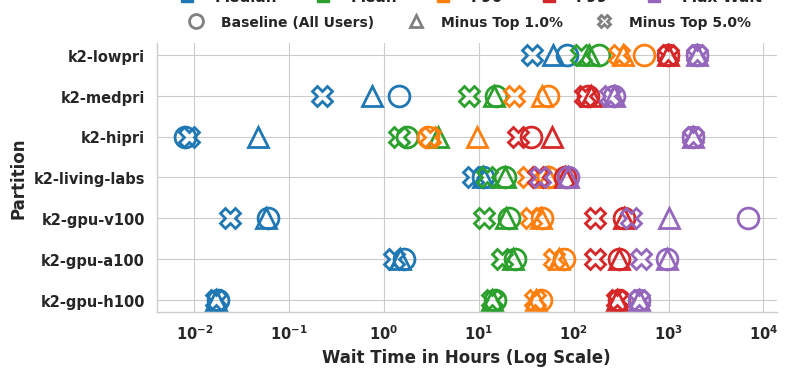

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))

edge_width = 2

for idx, col in enumerate(columns_to_plot):
    # Plot Baseline (All Users) - Hollow circles
    ax.plot(
        dist_base[col] + 0.001, 
        y_positions, 
        marker='o', 
        linestyle='', 
        markersize=15, 
        markerfacecolor='none', 
        markeredgewidth=edge_width,
        color=colors[idx]
    )
    
    # Plot Excluded 1.0% - Hollow triangles
    ax.plot(
        dist_excl_1[col] + 0.001, 
        y_positions, 
        marker='^', 
        linestyle='', 
        markersize=15, 
        markerfacecolor='none', 
        markeredgewidth=edge_width,
        color=colors[idx]
    )

    # Plot Excluded 5.0% - Hollow 'X' markers
    ax.plot(
        dist_excl_5[col] + 0.001, 
        y_positions, 
        marker='X', 
        linestyle='', 
        markersize=15, 
        markerfacecolor='none', 
        markeredgewidth=edge_width,
        color=colors[idx]
    )

# Formatting the axes
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_partitions)
ax.set_xscale('log')

font_label = {'weight': 'bold', 'size': 12}
ax.set_xlabel('Wait Time in Hours (Log Scale)', fontdict=font_label)
ax.set_ylabel('Partition', fontdict=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

metric_handles = [mlines.Line2D([], [], color=colors[i], marker='s', linestyle='', markersize=8, label=labels[i]) for i in range(len(labels))]
legend1 = ax.legend(handles=metric_handles, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=5, frameon=False, prop={'weight':'bold', 'size':11})
ax.add_artist(legend1)

marker_handles = [
    mlines.Line2D([], [], color='gray', marker='o', linestyle='', markersize=10, markerfacecolor='none', markeredgewidth=edge_width, label='Baseline (All Users)'),
    mlines.Line2D([], [], color='gray', marker='^', linestyle='', markersize=9, markerfacecolor='none', markeredgewidth=edge_width, label='Minus Top 1.0%'),
    mlines.Line2D([], [], color='gray', marker='X', linestyle='', markersize=9, markerfacecolor='none', markeredgewidth=edge_width, label='Minus Top 5.0%')
]
legend2 = ax.legend(handles=marker_handles, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False, prop={'weight':'bold', 'size':10})

ax.invert_yaxis()
sns.despine(ax=ax)

output_path = "wait_time_cleveland.pdf"

plt.savefig(
    output_path, 
    bbox_inches='tight', 
    bbox_extra_artists=(legend1, legend2), 
    format='pdf'
)
plt.show()